In [1]:
import pyzed.sl as sl
import cv2
import numpy as np
import threading
import time
import signal

import time
import threading
import matplotlib.pyplot as plt

In [ ]:
zed_list = []
img_list = []
timestamp_list = []
thread_list = []
stop_signal = False

timestamps = {
    'ZED_43957242': {
        'CURRENT': [],
        'IMAGE': []
    },
    'ZED_43916681': {
        'CURRENT': [],
        'IMAGE': []
    }
}


def signal_handler(signal, frame):
    global stop_signal
    stop_signal=True
    time.sleep(0.5)
    exit()

def grab_run(index):
    global stop_signal
    global zed_list
    global timestamp_list
    global img_list
    global name_list

    runtime = sl.RuntimeParameters()
    while not stop_signal:

        err = zed_list[index].grab(runtime)
        if err == sl.ERROR_CODE.SUCCESS:
            zed_list[index].retrieve_image(img_list[index], sl.VIEW.LEFT)
            current_timestamp = zed_list[index].get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns #time of function call
            image_timestamp= zed_list[index].get_timestamp(sl.TIME_REFERENCE.IMAGE).data_ns # time of frame extraction 

            timestamp_list[index] = current_timestamp
            timestamps[name_list[index]]['CURRENT'].append(current_timestamp)
            timestamps[name_list[index]]['IMAGE'].append(image_timestamp)
            

        time.sleep(0.001) #0.1ms
    zed_list[index].close()

def main():
    global stop_signal
    global zed_list
    global img_list
    global timestamp_list
    global thread_list
    global name_list
    signal.signal(signal.SIGINT, signal_handler)

    print("Running...")
    init = sl.InitParameters()
    init.camera_resolution = sl.RESOLUTION.HD1080
    init.camera_fps = 60  # The framerate is lowered to avoid any USB3 bandwidth issues

    #List and open cameras
    name_list = []
    last_ts_list = []
    cameras = sl.Camera.get_device_list()

    index = 0
    for cam in cameras:
        init.set_from_serial_number(cam.serial_number) # define input source
        name_list.append(f"ZED_{cam.serial_number}")
        print(f"Opening {name_list[index]}")
        zed_list.append(sl.Camera())
        img_list.append(sl.Mat())
        timestamp_list.append(0)
        last_ts_list.append(0)
        status = zed_list[index].open(init)
        if status != sl.ERROR_CODE.SUCCESS:
            print(repr(status))
            zed_list[index].close()
        index = index +1

    #Start camera threads
    for index in range(0, len(zed_list)):
        if zed_list[index].is_opened():
            thread_list.append(threading.Thread(target=grab_run, args=(index,)))
            thread_list[index].start()
    
    #Display camera images
    key = ''
    while key != 113:  # for 'q' key
        for cam_index in range(0, len(zed_list)):
            if zed_list[cam_index].is_opened():
                
                # if there is a new frame 
                if (timestamp_list[cam_index] > last_ts_list[cam_index]):
                    cv2.imshow(name_list[cam_index], cv2.resize(img_list[cam_index].get_data(),(800,600)))

                    # set the last timestamp for each cam to the current one of each cam 
                    last_ts_list[cam_index] = timestamp_list[cam_index]

        key = cv2.waitKey(10)
    cv2.destroyAllWindows()

    #Stop the threads
    stop_signal = True
    for index in range(0, len(thread_list)):
        thread_list[index].join()

    print("\nFINISH")

if __name__ == "__main__":
    main()

Running...
[2025-02-06 14:59:10 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:10 UTC][ZED][INFO] Logging level INFO
Opening ZED_43957242
[2025-02-06 14:59:11 UTC][ZED][INFO] Logging level INFO
Opening ZED_43916681
[2025-02-06 14:59:11 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:11 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:11 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-06 14:59:16 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-06 14:59:16 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-06 14:59:16 UTC][ZED][INFO] [Init]  Serial Number: S/N 43957242
[2025-02-06 14:59:17 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:17 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:17 UTC][ZED][INFO] Logging level INFO
[2025-02-06 14:59:17 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-06 14:59:21 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-06 14:59:21 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-06 14:5

### Plotting timestamps

In [68]:
## timestamps in ms for each camera
cam_1_current = np.array(timestamps['ZED_43957242']['CURRENT'])/1000000
cam_2_current = np.array(timestamps['ZED_43916681']['CURRENT'])/1000000

cam_1_img = np.array(timestamps['ZED_43957242']['IMAGE'])/1000000
cam_2_img = np.array(timestamps['ZED_43916681']['IMAGE'])/1000000

# print(timestamps.keys())
print(f'cam1 stamps: {cam_1_current.shape, cam_1_img.shape}')
print(f'cam2 stamps: {cam_2_current.shape, cam_2_img.shape}')

cam1 stamps: ((14310,), (14310,))
cam2 stamps: ((14298,), (14298,))


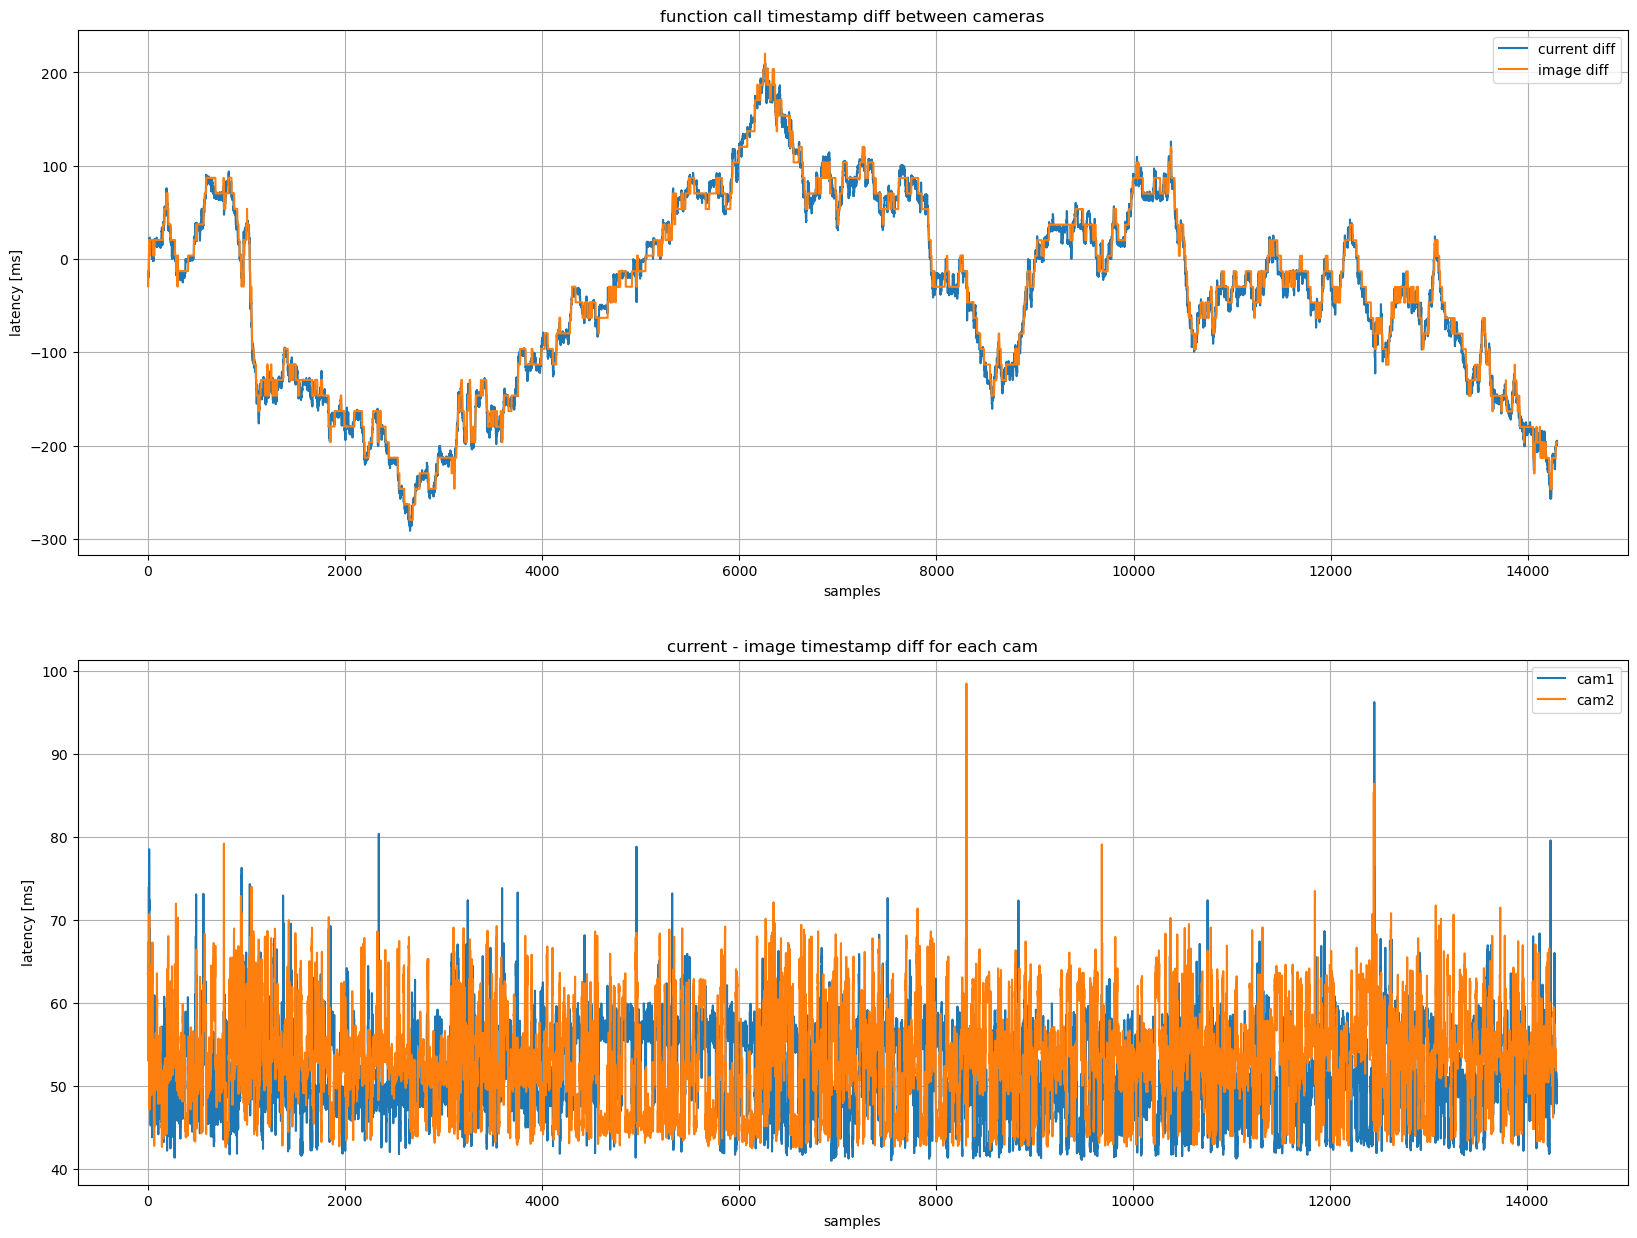

In [69]:
shorter_end_idx = min([len(cam_1_current),len(cam_2_current)])
current_vs_img_1 = cam_1_current-cam_1_img
current_vs_img_2 = cam_2_current-cam_2_img


plt.figure(figsize=(20,15))

plt.subplot(211)
plt.title('function call timestamp diff between cameras')
plt.plot(cam_1_current[:shorter_end_idx]-cam_2_current[:shorter_end_idx])
plt.plot(cam_1_img[:shorter_end_idx]-cam_2_img[:shorter_end_idx])
plt.legend(['current diff','image diff'])
# plt.yticks(np.linspace(-150,300,10))
plt.grid()
plt.xlabel('samples')
plt.ylabel('latency [ms]')


plt.subplot(212)
plt.title('current - image timestamp diff for each cam')
plt.plot(current_vs_img_1)
plt.plot(current_vs_img_2)
# plt.yticks(np.linspace(40,90,11))
plt.grid()
plt.xlabel('samples')
plt.ylabel('latency [ms]')
plt.legend(['cam1','cam2'])



In [71]:
np.save('./latency_2_cams_1.npy',np.array(timestamps))


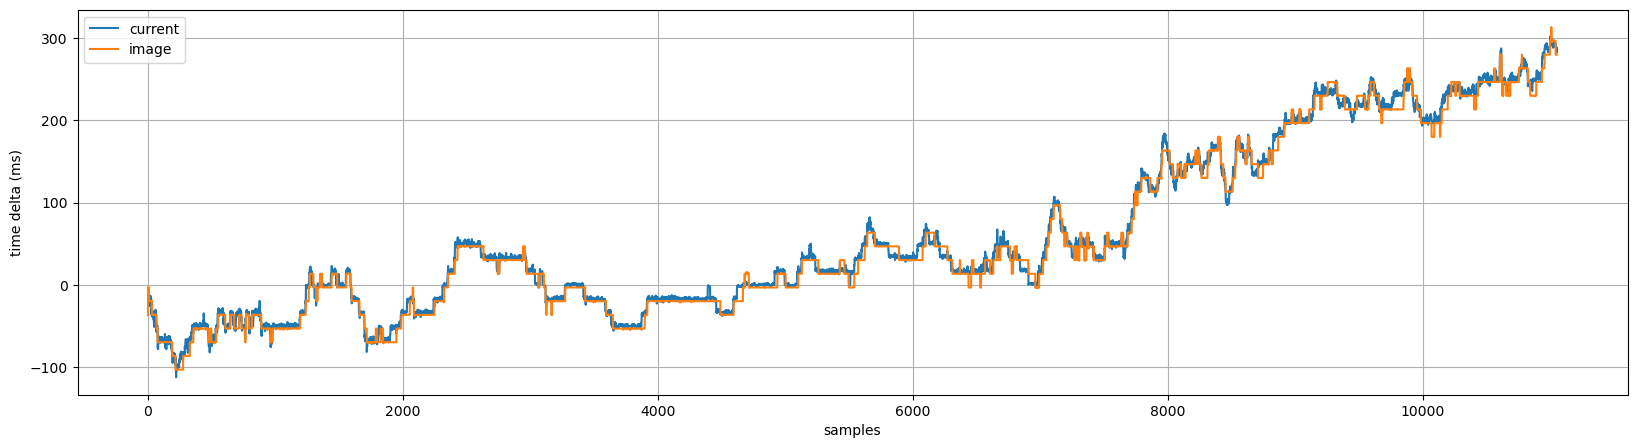

In [16]:
shorter_end_idx = min([len(cam_1_current),len(cam_2_current)])

diff_current = cam_1_current[:shorter_end_idx]-cam_2_current[:shorter_end_idx]

diff_img = cam_1_img[:shorter_end_idx]-cam_2_img[:shorter_end_idx]
# diff_1_shift = np.delete(cam_1_stamps[:shorter_end_idx],0)-cam_2_stamps[:shorter_end_idx-1]

# diff_other1_shift = cam_1_stamps[:shorter_end_idx-1] - np.delete(cam_2_stamps[:shorter_end_idx],0)

# diff_other5shift = cam_1_stamps[:shorter_end_idx-5] - cam_2_stamps[5:shorter_end_idx]

plt.figure(figsize=(20,5))
plt.plot(diff_current)
plt.plot(diff_img)
plt.ylabel('time delta (ms)')
plt.xlabel('samples')
plt.grid()
plt.legend(['current','image'])

In [5]:
np.save('./latency_2_cams_image_reference.npy', diff_no_shift)